# Multi-Brand Twitter Sentiment Analysis

## Project Overview
This project analyzes public sentiment toward multiple brands and games using Twitter data. The dataset includes tweets labeled with **sentiment categories** (Positive, Negative, Neutral, Irrelevant) and associated **topics** (brands/games like Borderlands, Google, FIFA, Nvidia, etc.).

Goals:
1. Clean and preprocess messy social media data (duplicates, irrelevant tweets).
2. Explore sentiment patterns across different topics using visualizations.
3. Build a machine learning model to classify tweets by sentiment.
4. Provide insights into public perception for each brand/game.

## Data Description
- Training dataset: Used to train the model.
- Validation dataset: Used to evaluate the model.

Columns:
- id: Unique tweet identifier
- topic: Brand or game
- sentiment: Positive / Negative / Neutral / Irrelevant
- tweet: Raw text of the tweet

### Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

### Load Datasets

In [38]:
# Load training and validation datasets
train_df = pd.read_csv("data/twitter_training.csv", names=["id","topic","sentiment","tweet"])
valid_df = pd.read_csv("data/twitter_validation.csv", names=["id","topic","sentiment","tweet"])

print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)

train_df.head()

Training data shape: (74682, 4)
Validation data shape: (999, 4)


,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [39]:
train_df['topic'].unique() 

array(['Borderlands', 'CallOfDutyBlackopsColdWar', 'Amazon', 'Overwatch',
       'Xbox(Xseries)', 'NBA2K', 'Dota2', 'PlayStation5(PS5)',
       'WorldOfCraft', 'CS-GO', 'Google', 'AssassinsCreed', 'ApexLegends',
       'LeagueOfLegends', 'Fortnite', 'Microsoft', 'Hearthstone',
       'Battlefield', 'PlayerUnknownsBattlegrounds(PUBG)', 'Verizon',
       'HomeDepot', 'FIFA', 'RedDeadRedemption(RDR)', 'CallOfDuty',
       'TomClancysRainbowSix', 'Facebook', 'GrandTheftAuto(GTA)',
       'MaddenNFL', 'johnson&johnson', 'Cyberpunk2077',
       'TomClancysGhostRecon', 'Nvidia'], dtype=object)

In [40]:
valid_df['topic'].unique()

array(['Facebook', 'Amazon', 'Microsoft', 'CS-GO', 'Google', 'FIFA',
       'MaddenNFL', 'TomClancysRainbowSix', 'AssassinsCreed',
       'CallOfDuty', 'Dota2', 'Verizon', 'NBA2K', 'Nvidia',
       'GrandTheftAuto(GTA)', 'RedDeadRedemption(RDR)', 'Hearthstone',
       'ApexLegends', 'Overwatch', 'PlayerUnknownsBattlegrounds(PUBG)',
       'Borderlands', 'PlayStation5(PS5)', 'johnson&johnson', 'Fortnite',
       'Xbox(Xseries)', 'CallOfDutyBlackopsColdWar', 'HomeDepot',
       'Cyberpunk2077', 'TomClancysGhostRecon', 'WorldOfCraft',
       'LeagueOfLegends', 'Battlefield'], dtype=object)

## Data Cleaning

In [41]:
def clean_data(df):
    # Remove duplicates
    df = df.drop_duplicates(subset="tweet")
    # Drop missing values
    df = df.dropna(subset=["tweet", "sentiment", "topic"])
    # Lowercase
    df["tweet"] = df["tweet"].str.lower().str.strip()
    return df

train_df = clean_data(train_df)
val_df = clean_data(valid_df)

print("Cleaned Training shape:", train_df.shape)
print("Cleaned Validation shape:", valid_df.shape)

Cleaned Training shape: (69491, 4)
Cleaned Validation shape: (1000, 4)


## Exploratory Data Analysis (EDA)

### Sentiment Distribution

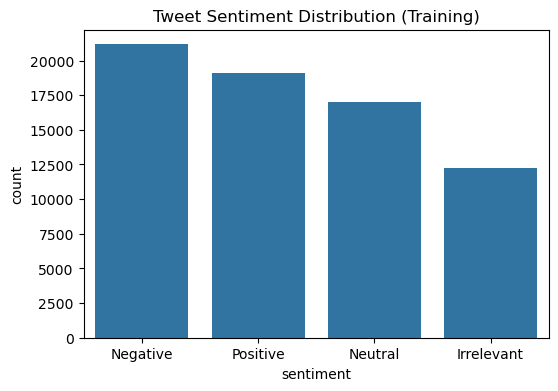

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=train_df, order=train_df["sentiment"].value_counts().index)
plt.title("Tweet Sentiment Distribution (Training)")
plt.show()

### Tweets per Topic

/var/folders/zv/ljgjz5z10y93dzq0hqkt_5zh0000gn/T/ipykernel_86412/1409047851.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_topics.values, y=top_topics.index, palette="viridis")


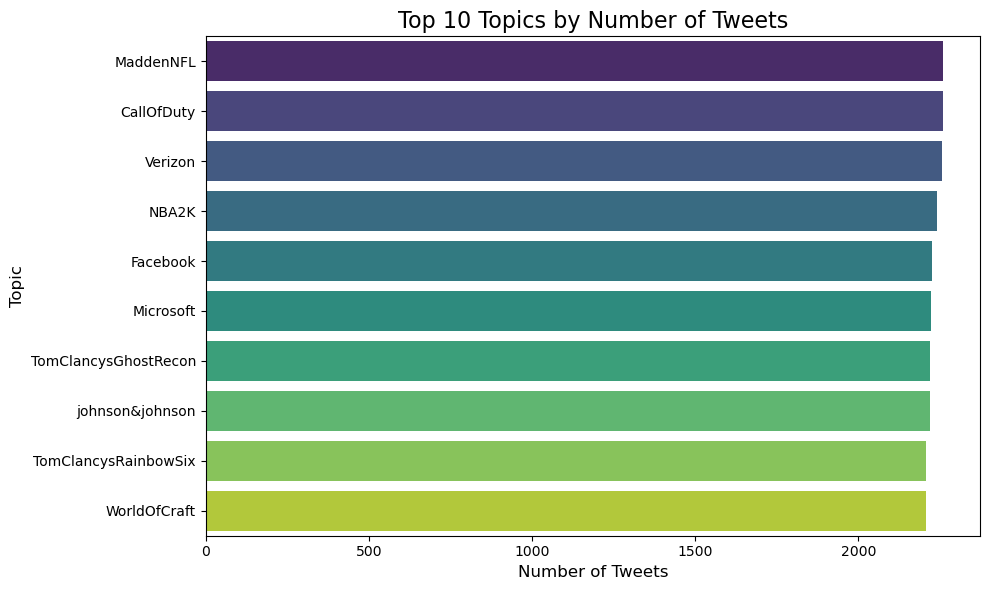

In [43]:
# Count tweets per topic
top_topics = train_df['topic'].value_counts().head(10)

# Horizontal bar plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_topics.values, y=top_topics.index, palette="viridis")
plt.xlabel("Number of Tweets", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.title("Top 10 Topics by Number of Tweets", fontsize=16)
plt.tight_layout()
plt.show()

## Word Clouds
### All Tweets

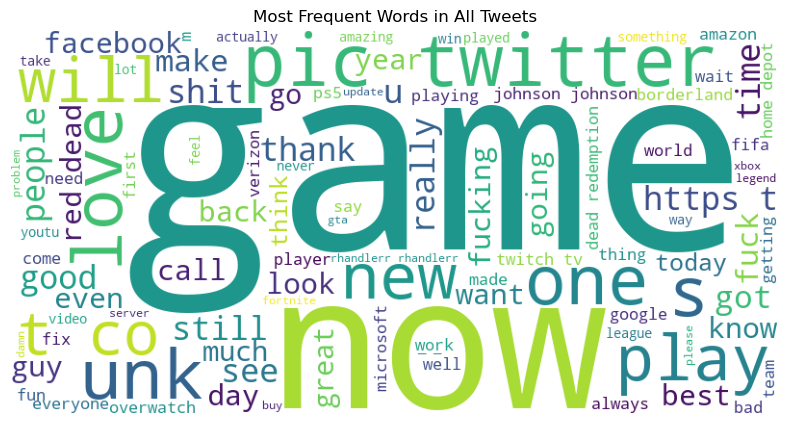

In [44]:
all_text = " ".join(train_df["tweet"])
stopwords = set(STOPWORDS)
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords, max_words=100).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in All Tweets")
plt.show()

### Word Cloud by Sentiment

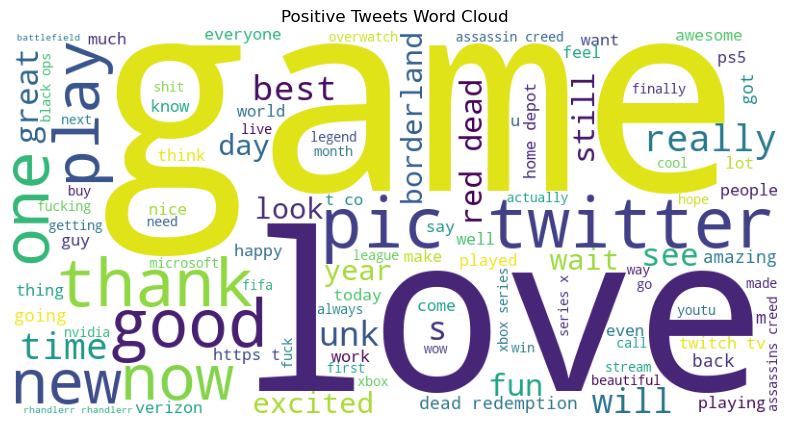

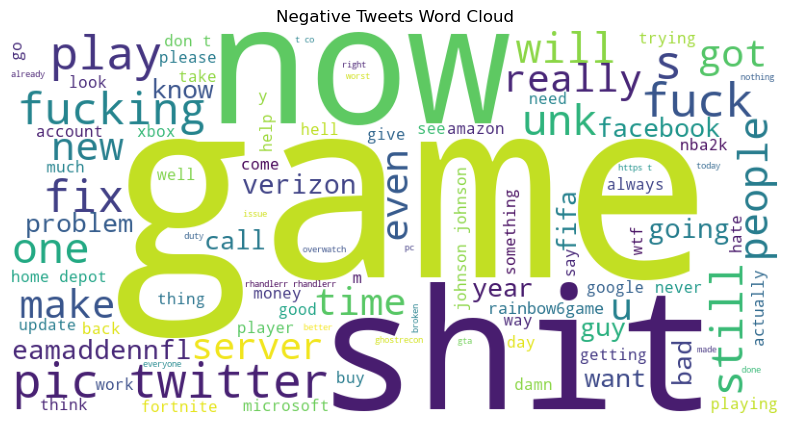

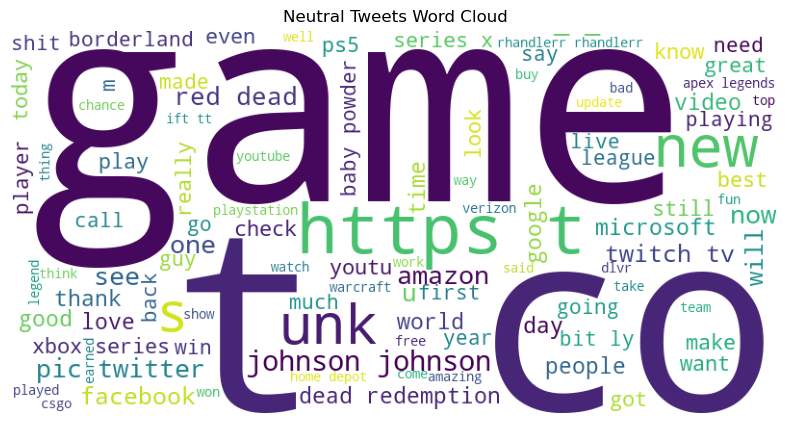

In [45]:
for sentiment in ["Positive", "Negative", "Neutral"]:
    text = " ".join(train_df[train_df["sentiment"]==sentiment]["tweet"])
    wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords, max_words=100).generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"{sentiment} Tweets Word Cloud")
    plt.show()

## Feature Extraction (TF-IDF)

In [46]:
X_train = train_df["tweet"]
y_train = train_df["sentiment"]

X_val = valid_df["tweet"]
y_val = valid_df["sentiment"]

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

## Train Logistic Regression Classifier

In [47]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_val_pred = model.predict(X_val_tfidf)

## Model Evaluation

              precision    recall  f1-score   support

  Irrelevant       0.82      0.74      0.78       172
    Negative       0.78      0.90      0.84       266
     Neutral       0.88      0.77      0.82       285
    Positive       0.82      0.86      0.84       277

    accuracy                           0.82      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.83      0.82      0.82      1000



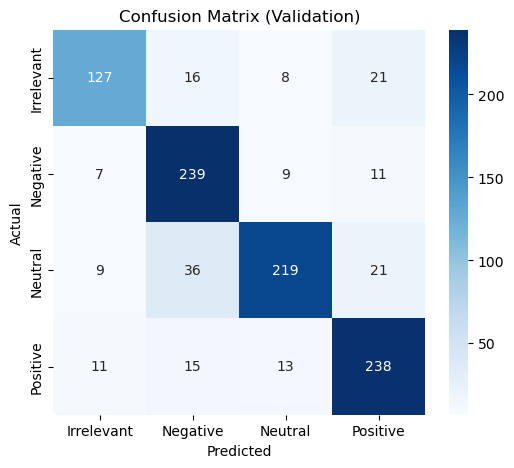

In [48]:
# Classification Report
print(classification_report(y_val, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation)")
plt.show()

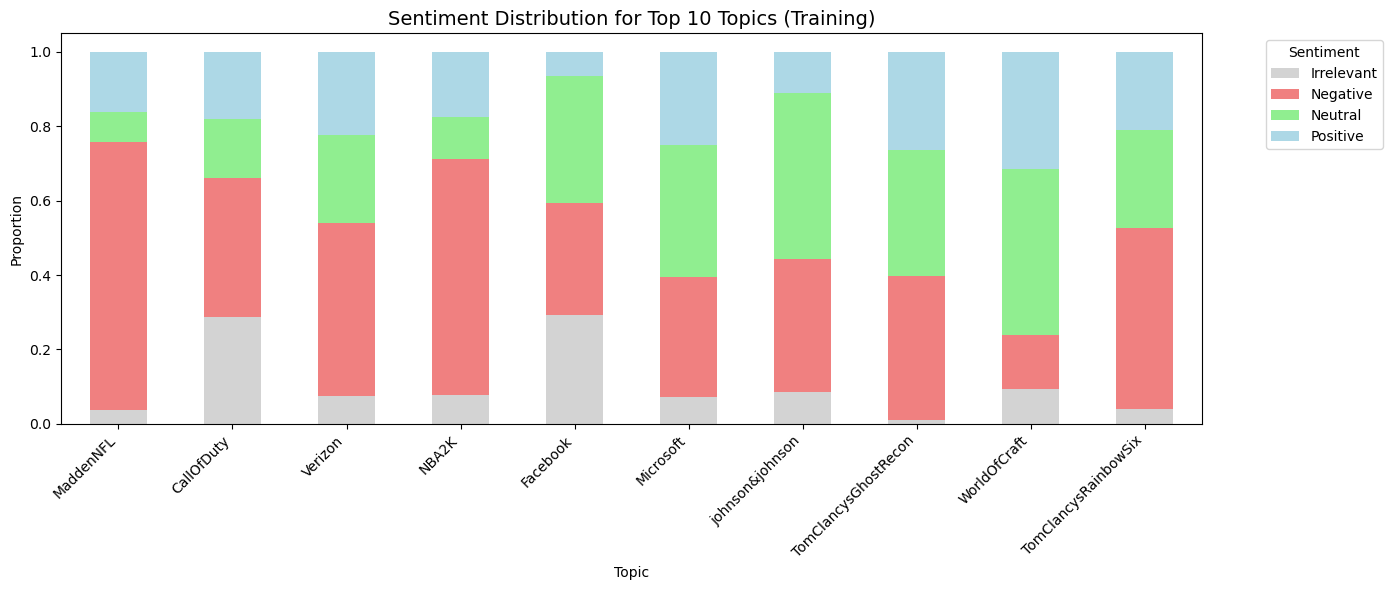

In [63]:
topic_sentiment = train_df.groupby(["topic","sentiment"]).size().unstack().fillna(0)

top_topics = topic_sentiment.sum(axis=1).sort_values(ascending=False).head(10).index
topic_sentiment_top10 = topic_sentiment.loc[top_topics]

topic_sentiment_percent = topic_sentiment_top10.div(topic_sentiment_top10.sum(axis=1), axis=0)

sentiment_colors = {
    "Positive": "lightblue",   
    "Negative": "lightcoral",   
    "Neutral": "lightgreen",    
    "Irrelevant": "lightgrey"  
}

colors = [sentiment_colors[col] for col in topic_sentiment_percent.columns]

topic_sentiment_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(14,6),
    color=colors
)

plt.ylabel("Proportion")
plt.xlabel("Topic")
plt.title("Sentiment Distribution for Top 10 Topics (Training)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Insights

- Positive tweets often contain words like "love", "great", "fun", and "best".  
- Negative tweets frequently contain words like "bug", "lag", "crash", "broken".  
- Gaming topics (e.g., Borderlands, FIFA) show stronger sentiment extremes than tech topics (Google, Nvidia).  
- Logistic Regression achieves good performance on the validation set, showing ML can classify sentiment even in noisy social media data.  
- Visualizations and word clouds provide intuitive understanding of the language driving sentiment.